In [58]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the datasets

In [59]:
credits = pd.read_csv(r"E:\Recommender Project\Datasets\final merged datasets\tmdb_credits_extended.csv")
movies = pd.read_csv(r"E:\Recommender Project\Datasets\final merged datasets\tmdb_movies_extended.csv")

In [60]:
movies.shape, credits.shape

((20842, 20), (20842, 4))

In [61]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                20842 non-null  int64  
 1   genres                20842 non-null  object 
 2   homepage              9078 non-null   object 
 3   id                    20842 non-null  int64  
 4   keywords              20842 non-null  object 
 5   original_language     20842 non-null  object 
 6   original_title        20841 non-null  object 
 7   overview              20757 non-null  object 
 8   popularity            20842 non-null  float64
 9   production_companies  20842 non-null  object 
 10  production_countries  20842 non-null  object 
 11  release_date          20841 non-null  object 
 12  revenue               20842 non-null  int64  
 13  runtime               20840 non-null  float64
 14  spoken_languages      20842 non-null  object 
 15  status             

## Merging the two datasets based on ids

In [62]:
df = pd.merge(movies, credits, left_on='id', right_on='movie_id', how='inner')

In [63]:
df.shape

(20842, 24)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                20842 non-null  int64  
 1   genres                20842 non-null  object 
 2   homepage              9078 non-null   object 
 3   id                    20842 non-null  int64  
 4   keywords              20842 non-null  object 
 5   original_language     20842 non-null  object 
 6   original_title        20841 non-null  object 
 7   overview              20757 non-null  object 
 8   popularity            20842 non-null  float64
 9   production_companies  20842 non-null  object 
 10  production_countries  20842 non-null  object 
 11  release_date          20841 non-null  object 
 12  revenue               20842 non-null  int64  
 13  runtime               20840 non-null  float64
 14  spoken_languages      20842 non-null  object 
 15  status             

## Dropping redundant column and renaming the existing column

In [65]:
df.drop(columns=['movie_id','title_y'], inplace=True)
df.rename(columns={'title_x':'title'}, inplace=True)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                20842 non-null  int64  
 1   genres                20842 non-null  object 
 2   homepage              9078 non-null   object 
 3   id                    20842 non-null  int64  
 4   keywords              20842 non-null  object 
 5   original_language     20842 non-null  object 
 6   original_title        20841 non-null  object 
 7   overview              20757 non-null  object 
 8   popularity            20842 non-null  float64
 9   production_companies  20842 non-null  object 
 10  production_countries  20842 non-null  object 
 11  release_date          20841 non-null  object 
 12  revenue               20842 non-null  int64  
 13  runtime               20840 non-null  float64
 14  spoken_languages      20842 non-null  object 
 15  status             

## Data Cleaning

In [67]:
df_copy = df.copy()
df_copy.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


### Homepage more than 50% is empty and is absolutely useless. Dropping homepage column

In [68]:
df_copy.drop(columns=['homepage'], inplace=True)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                20842 non-null  int64  
 1   genres                20842 non-null  object 
 2   id                    20842 non-null  int64  
 3   keywords              20842 non-null  object 
 4   original_language     20842 non-null  object 
 5   original_title        20841 non-null  object 
 6   overview              20757 non-null  object 
 7   popularity            20842 non-null  float64
 8   production_companies  20842 non-null  object 
 9   production_countries  20842 non-null  object 
 10  release_date          20841 non-null  object 
 11  revenue               20842 non-null  int64  
 12  runtime               20840 non-null  float64
 13  spoken_languages      20842 non-null  object 
 14  status                20842 non-null  object 
 15  tagline            

### We have to fix each column one by one into features. 

### Starting with the genres column

In [69]:
df_copy["genres"]

0        [{"id": 28, "name": "Action"}, {"id": 12, "nam...
1        [{"id": 12, "name": "Adventure"}, {"id": 14, "...
2        [{"id": 28, "name": "Action"}, {"id": 12, "nam...
3        [{"id": 28, "name": "Action"}, {"id": 80, "nam...
4        [{"id": 28, "name": "Action"}, {"id": 12, "nam...
                               ...                        
20837                  [{"id": 99, "name": "Documentary"}]
20838    [{"id": 16, "name": "Animation"}, {"id": 35, "...
20839                  [{"id": 99, "name": "Documentary"}]
20840    [{"id": 16, "name": "Animation"}, {"id": 35, "...
20841    [{"id": 16, "name": "Animation"}, {"id": 35, "...
Name: genres, Length: 20842, dtype: object

In [70]:
## Max length of the list of genres in the column
import ast ##It is used to safely evaluate strings containing Python expressions from untrusted sources.
df_copy["genres"] = df_copy["genres"].apply(ast.literal_eval)
max_genre_length = df_copy["genres"].apply(len).max()
max_genre_length ##Maximum number of genres in a movie is 7

np.int64(7)

<Axes: xlabel='genres_count'>

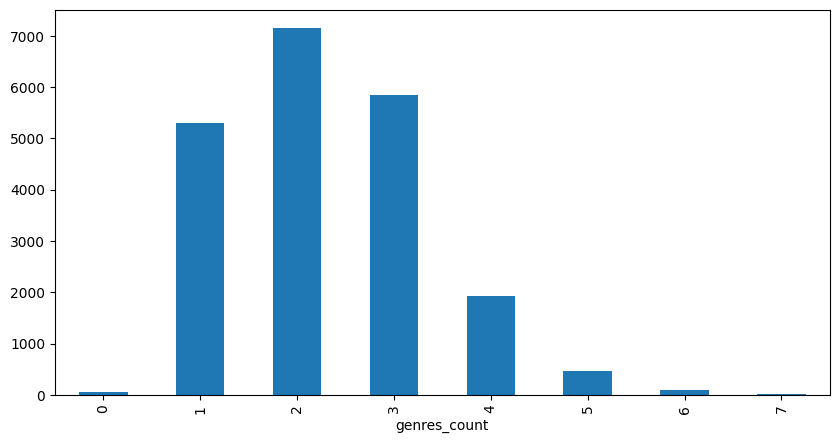

In [71]:
#Distribution of number of genres in the movies
df_copy['genres_count'] = df_copy['genres'].apply(len)
df_copy['genres_count'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))

In [72]:
##Converted from dictionary to list of genres and string of genres with underscore instead of space for each genre
df_copy['genres'] = df_copy['genres'].apply(lambda x: [g['name'] for g in x])
df_copy['genres_str'] = df_copy['genres'].apply(lambda lst: ' '.join(g.replace(' ', '_') for g in lst))

In [73]:
## Converting Genres strings to a TFIDF matrix.
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
genre_matrix = tfidf.fit_transform(df_copy['genres_str'])
print(tfidf.get_feature_names_out())
print(genre_matrix.toarray())

['action' 'adventure' 'animation' 'comedy' 'crime' 'documentary' 'drama'
 'family' 'fantasy' 'foreign' 'history' 'horror' 'music' 'mystery'
 'romance' 'science_fiction' 'thriller' 'tv_movie' 'war' 'western']
[[0.41721541 0.50253687 0.         ... 0.         0.         0.        ]
 [0.49250132 0.59321891 0.         ... 0.         0.         0.        ]
 [0.51558561 0.621024   0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.70222877 ... 0.         0.         0.        ]
 [0.         0.         0.67467435 ... 0.         0.         0.        ]]


In [74]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                20842 non-null  int64  
 1   genres                20842 non-null  object 
 2   id                    20842 non-null  int64  
 3   keywords              20842 non-null  object 
 4   original_language     20842 non-null  object 
 5   original_title        20841 non-null  object 
 6   overview              20757 non-null  object 
 7   popularity            20842 non-null  float64
 8   production_companies  20842 non-null  object 
 9   production_countries  20842 non-null  object 
 10  release_date          20841 non-null  object 
 11  revenue               20842 non-null  int64  
 12  runtime               20840 non-null  float64
 13  spoken_languages      20842 non-null  object 
 14  status                20842 non-null  object 
 15  tagline            

### Keywords Column Cleaning

In [75]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                20842 non-null  int64  
 1   genres                20842 non-null  object 
 2   id                    20842 non-null  int64  
 3   keywords              20842 non-null  object 
 4   original_language     20842 non-null  object 
 5   original_title        20841 non-null  object 
 6   overview              20757 non-null  object 
 7   popularity            20842 non-null  float64
 8   production_companies  20842 non-null  object 
 9   production_countries  20842 non-null  object 
 10  release_date          20841 non-null  object 
 11  revenue               20842 non-null  int64  
 12  runtime               20840 non-null  float64
 13  spoken_languages      20842 non-null  object 
 14  status                20842 non-null  object 
 15  tagline            

In [76]:
df_copy['keywords'][0]

'[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]'

#### Similar EDA and Feature Cleaning as Genre Column.

In [77]:
df_copy['keywords'] = df_copy['keywords'].apply(ast.literal_eval)
df_copy['keywords'][0]

[{'id': 1463, 'name': 'culture clash'},
 {'id': 2964, 'name': 'future'},
 {'id': 3386, 'name': 'space war'},
 {'id': 3388, 'name': 'space colony'},
 {'id': 3679, 'name': 'society'},
 {'id': 3801, 'name': 'space travel'},
 {'id': 9685, 'name': 'futuristic'},
 {'id': 9840, 'name': 'romance'},
 {'id': 9882, 'name': 'space'},
 {'id': 9951, 'name': 'alien'},
 {'id': 10148, 'name': 'tribe'},
 {'id': 10158, 'name': 'alien planet'},
 {'id': 10987, 'name': 'cgi'},
 {'id': 11399, 'name': 'marine'},
 {'id': 13065, 'name': 'soldier'},
 {'id': 14643, 'name': 'battle'},
 {'id': 14720, 'name': 'love affair'},
 {'id': 165431, 'name': 'anti war'},
 {'id': 193554, 'name': 'power relations'},
 {'id': 206690, 'name': 'mind and soul'},
 {'id': 209714, 'name': '3d'}]

<Axes: xlabel='keywords'>

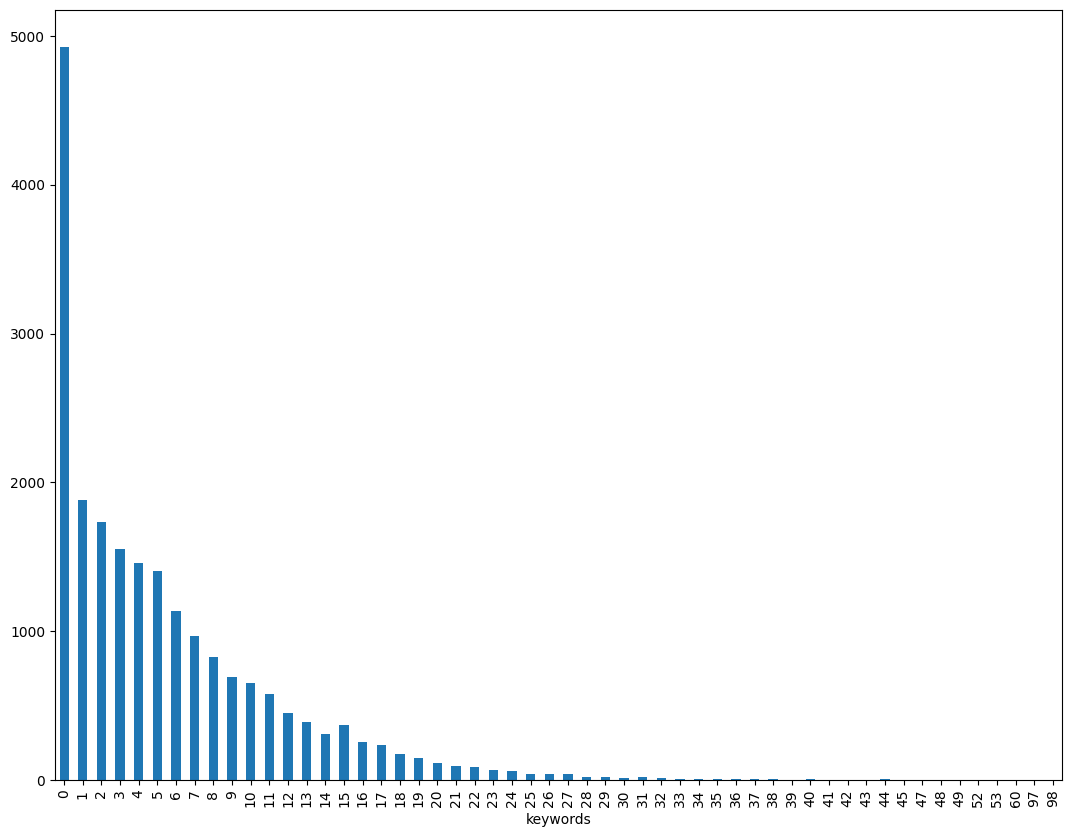

In [78]:
## Distribution of keywords 
## Highly Skewed distribution of keywords. Most of the movies have less than 10 keywords. Some movies have more than 100 keywords.
df_copy['keywords'].apply(len).value_counts().sort_index().plot(kind='bar', figsize=(13,10))

In [79]:
## Converting the keywords column from list of dictionaries to list of keywords and string of keywords with underscore instead of space for each keyword
df_copy['keywords'] = df_copy['keywords'].apply(lambda x: [g['name'] for g in x])
df_copy['keywords_str'] = df_copy['keywords'].apply(lambda lst: ' '.join(g.replace(' ', '_') for g in lst))

In [80]:
df_copy.head(1)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,status,tagline,title,vote_average,vote_count,cast,crew,genres_count,genres_str,keywords_str
0,237000000,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",4,Action Adventure Fantasy Science_Fiction,culture_clash future space_war space_colony so...


In [81]:
##Converting into TFIDF matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
tfidf = TfidfVectorizer(min_df = 5, max_features = 5000)
tfidf_keywords_matrix = tfidf.fit_transform(df_copy['keywords_str'])

svd = TruncatedSVD(n_components=300, random_state=42)
keywords_matrix = svd.fit_transform(tfidf_keywords_matrix)

### Overview Column Cleaning

In [82]:
df_copy['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [83]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADRIJO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADRIJO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [84]:
def lemmatize_text(text):
    if pd.isna(text):
        return ''
    words = text.split()
    words = [w for w in words if w.lower() not in stop_words]  # remove stopwords first
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]  # then lemmatize
    return ' '.join(lemmatized_words)

In [85]:
df_copy['overview'] = df_copy['overview'].apply(lemmatize_text)

In [86]:
tfidf = TfidfVectorizer(stop_words='english', min_df=5, max_features=5000)
overview_tfidf = tfidf.fit_transform(df_copy['overview'])

svd = TruncatedSVD(n_components=800, random_state=42)
overview_matrix = svd.fit_transform(overview_tfidf)  # (20842, 200)

### Creating Weighted Rating Feature out of vote_count and vote_average

In [87]:
C = df_copy['vote_average'].mean()          # overall average rating across the dataset (here: 6.287)
m = df_copy['vote_count'].quantile(0.90)     # votes threshold — here: 973

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

df_copy['weighted_rating'] = df_copy.apply(weighted_rating, axis=1)

### Extacting the top 4 cast and movie director from cast and crew.

In [88]:
##Making the cast and crew lists
df_copy['cast'] = df_copy['cast'].apply(ast.literal_eval)
df_copy['crew'] = df_copy['crew'].apply(ast.literal_eval)

In [89]:
df_copy['cast'][0]

[{'cast_id': 242,
  'character': 'Jake Sully',
  'credit_id': '5602a8a7c3a3685532001c9a',
  'gender': 2,
  'id': 65731,
  'name': 'Sam Worthington',
  'order': 0},
 {'cast_id': 3,
  'character': 'Neytiri',
  'credit_id': '52fe48009251416c750ac9cb',
  'gender': 1,
  'id': 8691,
  'name': 'Zoe Saldana',
  'order': 1},
 {'cast_id': 25,
  'character': 'Dr. Grace Augustine',
  'credit_id': '52fe48009251416c750aca39',
  'gender': 1,
  'id': 10205,
  'name': 'Sigourney Weaver',
  'order': 2},
 {'cast_id': 4,
  'character': 'Col. Quaritch',
  'credit_id': '52fe48009251416c750ac9cf',
  'gender': 2,
  'id': 32747,
  'name': 'Stephen Lang',
  'order': 3},
 {'cast_id': 5,
  'character': 'Trudy Chacon',
  'credit_id': '52fe48009251416c750ac9d3',
  'gender': 1,
  'id': 17647,
  'name': 'Michelle Rodriguez',
  'order': 4},
 {'cast_id': 8,
  'character': 'Selfridge',
  'credit_id': '52fe48009251416c750ac9e1',
  'gender': 2,
  'id': 1771,
  'name': 'Giovanni Ribisi',
  'order': 5},
 {'cast_id': 7,
  'c

In [90]:
def extract_top_4(df):
    count = 0
    cast = ''
    for i in df:
        if count < 4:
            cast += i['name'].replace(' ', '_') + ' '
            count += 1
    return cast

df_copy['cast'] = df_copy['cast'].apply(extract_top_4)
df_copy['cast'][0]

'Sam_Worthington Zoe_Saldana Sigourney_Weaver Stephen_Lang '

In [91]:
def fetch_director(df):
    for i in df:
        if i['job'] == 'Director':
            return i['name'].replace(' ', '_')
    return ''

df_copy['director'] = df_copy['crew'].apply(fetch_director)
df_copy['director'][0]

'James_Cameron'

### Fetching the Production Companies

In [92]:
df_copy['production_companies'] = df_copy['production_companies'].apply(
    lambda x: [g['name'] for g in ast.literal_eval(x)] if pd.notna(x) else []
)
df_copy['production_companies'][0]

['Ingenious Film Partners',
 'Twentieth Century Fox Film Corporation',
 'Dune Entertainment',
 'Lightstorm Entertainment']

In [93]:
STUDIO_MAP = {
    # Marvel
    'Marvel Studios': 'Marvel', 'Marvel Entertainment': 'Marvel',
    'Marvel Enterprises': 'Marvel', 'Marvel Animation': 'Marvel',
    'Marvel Knights': 'Marvel', 'Marvel New Media': 'Marvel',

    # DC
    'DC Comics': 'DC', 'DC Entertainment': 'DC',
    'DC Films': 'DC', 'DC Studios': 'DC', 'DC Vertigo': 'DC',

    # Disney / Pixar
    'Walt Disney Pictures': 'Disney', 'Walt Disney Productions': 'Disney',
    'Walt Disney Animation Studios': 'Disney', 'Walt Disney Studios Motion Pictures': 'Disney',
    'Disney': 'Disney', 'Disney Enterprises, Inc.': 'Disney', 'DisneyToon Studios': 'Disney',
    'Disneynature': 'Disney', 'Pixar': 'Disney', 'Pixar Animation Studios': 'Disney',

    # Warner Bros (film only — excludes Warner Music/Television intentionally)
    'Warner Bros.': 'Warner Bros', 'Warner Bros. Pictures': 'Warner Bros',
    'Warner Animation Group': 'Warner Bros', 'Warner Independent Pictures (WIP)': 'Warner Bros',

    # Universal (film only — excludes Universal Music)
    'Universal': 'Universal', 'Universal Pictures': 'Universal',
    'Universal Studios': 'Universal', 'Universal City Studios': 'Universal',
    'Universal Pictures Corporation': 'Universal', 'Universal Animation Studios': 'Universal',

    # Paramount
    'Paramount': 'Paramount', 'Paramount Pictures': 'Paramount',
    'Paramount Animation': 'Paramount', 'Paramount Vantage': 'Paramount',

    # Sony (film only — excludes Sony Music)
    'Sony': 'Sony Pictures', 'Sony Pictures': 'Sony Pictures',
    'Sony Pictures Entertainment': 'Sony Pictures', 'Sony Pictures Animation': 'Sony Pictures',
    'Sony Pictures Classics': 'Sony Pictures', 'Sony Pictures Imageworks': 'Sony Pictures',

    # Columbia (historically merged into Sony, but keep separate — distinct brand identity)
    'Columbia Pictures': 'Columbia Pictures', 'Columbia Pictures Corporation': 'Columbia Pictures',
    'Columbia Pictures Industries': 'Columbia Pictures',

    # MGM
    'MGM': 'MGM', 'Metro-Goldwyn-Mayer': 'MGM', 'Metro-Goldwyn-Mayer (MGM)': 'MGM',
    'Metro-Goldwyn-Mayer Pictures': 'MGM', 'Amazon MGM Studios': 'MGM',

    # Lionsgate
    'LionsGate': 'Lionsgate', 'Lionsgate': 'Lionsgate', 'Lionsgate Premiere': 'Lionsgate',

    # Lucasfilm
    'Lucasfilm': 'Lucasfilm', 'Lucasfilm Ltd.': 'Lucasfilm',

    # 20th Century Fox / Studios — exact matches only, NOT a "fox" substring rule
    '20th Century Fox': '20th Century Studios', '20th Century Studios': '20th Century Studios',
    'Twentieth Century Fox Film Corporation': '20th Century Studios',
    '20th Century Fox Animation': '20th Century Studios',
    'Twentieth Century Fox Animation': '20th Century Studios',
    'Fox Searchlight Pictures': 'Fox Searchlight',  # kept separate — distinct indie-film brand identity

    # New Line
    'New Line Cinema': 'New Line', 'New Line Productions': 'New Line',

    # Legendary
    'Legendary Pictures': 'Legendary', 'Legendary Entertainment': 'Legendary',

    # DreamWorks
    'DreamWorks': 'DreamWorks', 'DreamWorks Animation': 'DreamWorks',
    'DreamWorks Pictures': 'DreamWorks', 'DreamWorks SKG': 'DreamWorks',
    'Dreamworks Pictures': 'DreamWorks',

    # Illumination
    'Illumination': 'Illumination', 'Illumination Entertainment': 'Illumination',

    # Miramax / Weinstein
    'Miramax': 'Miramax', 'Miramax Films': 'Miramax',
    'The Weinstein Company': 'Weinstein Company', 'Weinstein Company, The': 'Weinstein Company',

    # Netflix / Amazon
    'NetFlix': 'Netflix', 'Netflix': 'Netflix',
    'Amazon Studios': 'Amazon Studios',

    # Blumhouse, A24, Ghibli, Focus — already single/consistent, no mapping needed
}

def normalize_company(name):
    return STUDIO_MAP.get(name, name)  # unmapped names pass through unchanged

df_copy['production_companies_normalized'] = df_copy['production_companies'].apply(lambda lst: [normalize_company(c) for c in lst])

In [94]:
from collections import Counter
counts = Counter()
for lst in df_copy['production_companies_normalized']:
    counts.update(lst)
min_movies = 20
keep_companies = {name for name, c in counts.items() if c >= min_movies}
df_copy['production_companies_filtered'] = df_copy['production_companies_normalized'].apply(
    lambda lst: [c for c in lst if c in keep_companies]
)

In [95]:
df_copy['production_companies_filtered'].head(5)

0    [Ingenious Film Partners, 20th Century Studios...
1                    [Disney, Jerry Bruckheimer Films]
2                                  [Columbia Pictures]
3                         [Legendary, Warner Bros, DC]
4                                             [Disney]
Name: production_companies_filtered, dtype: object

### Will Drop some of the columns that will just add unnecessary noise

In [96]:
df_copy.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'cast', 'crew', 'genres_count', 'genres_str',
       'keywords_str', 'weighted_rating', 'director',
       'production_companies_normalized', 'production_companies_filtered'],
      dtype='object')

In [97]:
df_copy.drop(columns=['original_language','production_countries','release_date','spoken_languages','status','tagline','title','genres_count','genres_str','keywords_str','revenue','vote_average','vote_count','crew','production_companies','production_companies_normalized'], inplace=True)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   budget                         20842 non-null  int64  
 1   genres                         20842 non-null  object 
 2   id                             20842 non-null  int64  
 3   keywords                       20842 non-null  object 
 4   original_title                 20841 non-null  object 
 5   overview                       20842 non-null  object 
 6   popularity                     20842 non-null  float64
 7   runtime                        20840 non-null  float64
 8   cast                           20842 non-null  object 
 9   weighted_rating                20842 non-null  float64
 10  director                       20842 non-null  object 
 11  production_companies_filtered  20842 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usag

In [98]:
df_copy.drop(['budget','runtime'], axis=1, inplace=True)
df_copy.head()

,genres,id,keywords,original_title,overview,popularity,cast,weighted_rating,director,production_companies_filtered
0,"[Action, Adventure, Fantasy, Science Fiction]",19995,"[culture clash, future, space war, space colon...",Avatar,"22nd century, paraplegic Marine dispatched moo...",150.437577,Sam_Worthington Zoe_Saldana Sigourney_Weaver S...,7.130448,James_Cameron,"[Ingenious Film Partners, 20th Century Studios..."
1,"[Adventure, Fantasy, Action]",285,"[ocean, drug abuse, exotic island, east india ...",Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed dead, come bac...",139.082615,Johnny_Depp Orlando_Bloom Keira_Knightley Stel...,6.791012,Gore_Verbinski,"[Disney, Jerry Bruckheimer Films]"
2,"[Action, Adventure, Crime]",206647,"[spy, based on novel, secret agent, sequel, mi...",Spectre,cryptic message Bond’s past sends trail uncove...,107.376788,Daniel_Craig Christoph_Waltz Léa_Seydoux Ralph...,6.297666,Sam_Mendes,[Columbia Pictures]
3,"[Action, Crime, Drama, Thriller]",49026,"[dc comics, crime fighter, terrorist, secret i...",The Dark Knight Rises,"Following death District Attorney Harvey Dent,...",112.312950,Christian_Bale Michael_Caine Gary_Oldman Anne_...,7.473242,Christopher_Nolan,"[Legendary, Warner Bros, DC]"
4,"[Action, Adventure, Science Fiction]",49529,"[based on novel, mars, medallion, space travel...",John Carter,"John Carter war-weary, former military captain...",43.926995,Taylor_Kitsch Lynn_Collins Samantha_Morton Wil...,6.158736,Andrew_Stanton,[Disney]


In [99]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20842 entries, 0 to 20841
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   genres                         20842 non-null  object 
 1   id                             20842 non-null  int64  
 2   keywords                       20842 non-null  object 
 3   original_title                 20841 non-null  object 
 4   overview                       20842 non-null  object 
 5   popularity                     20842 non-null  float64
 6   cast                           20842 non-null  object 
 7   weighted_rating                20842 non-null  float64
 8   director                       20842 non-null  object 
 9   production_companies_filtered  20842 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.6+ MB


In [100]:
##Dropping the null row in original_title column
df_copy.dropna(subset=['original_title'], inplace=True)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20841 entries, 0 to 20841
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   genres                         20841 non-null  object 
 1   id                             20841 non-null  int64  
 2   keywords                       20841 non-null  object 
 3   original_title                 20841 non-null  object 
 4   overview                       20841 non-null  object 
 5   popularity                     20841 non-null  float64
 6   cast                           20841 non-null  object 
 7   weighted_rating                20841 non-null  float64
 8   director                       20841 non-null  object 
 9   production_companies_filtered  20841 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.7+ MB


## EDA

### Exploring the columns which has almost all the columns empty or null

In [105]:
df_copy[df_copy['director'] == ''].shape

(93, 10)

In [107]:
df_copy[df_copy['keywords'].str.len() == 0].shape

(4929, 10)

In [109]:
df_copy[df_copy['production_companies_filtered'].str.len() == 0].shape

(9790, 10)

In [ ]:
df_copy[df_copy['overview'].str.len() == 0].shape

(86, 10)

In [113]:
df_copy[df_copy['cast'].str.len() == 0].shape

(224, 10)

#### Now finding out the rows in which most of these columns are empty

#### I am not trying to remove all the null columns because we will lose a lot of data. And the null values in the matrix calculation will just give 0 as a result and not interfere in the prediction.

In [121]:
bad_row_conditions = (df_copy['director'].str.len() == 0) & (df_copy['keywords'].str.len() == 0) & (df_copy['production_companies_filtered'].str.len() == 0) & (df_copy['overview'].str.len() == 0) & (df_copy['cast'].str.len() == 0)
df_copy = df_copy[~bad_row_conditions]

In [122]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20837 entries, 0 to 20841
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   genres                         20837 non-null  object 
 1   id                             20837 non-null  int64  
 2   keywords                       20837 non-null  object 
 3   original_title                 20837 non-null  object 
 4   overview                       20837 non-null  object 
 5   popularity                     20837 non-null  float64
 6   cast                           20837 non-null  object 
 7   weighted_rating                20837 non-null  float64
 8   director                       20837 non-null  object 
 9   production_companies_filtered  20837 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.7+ MB


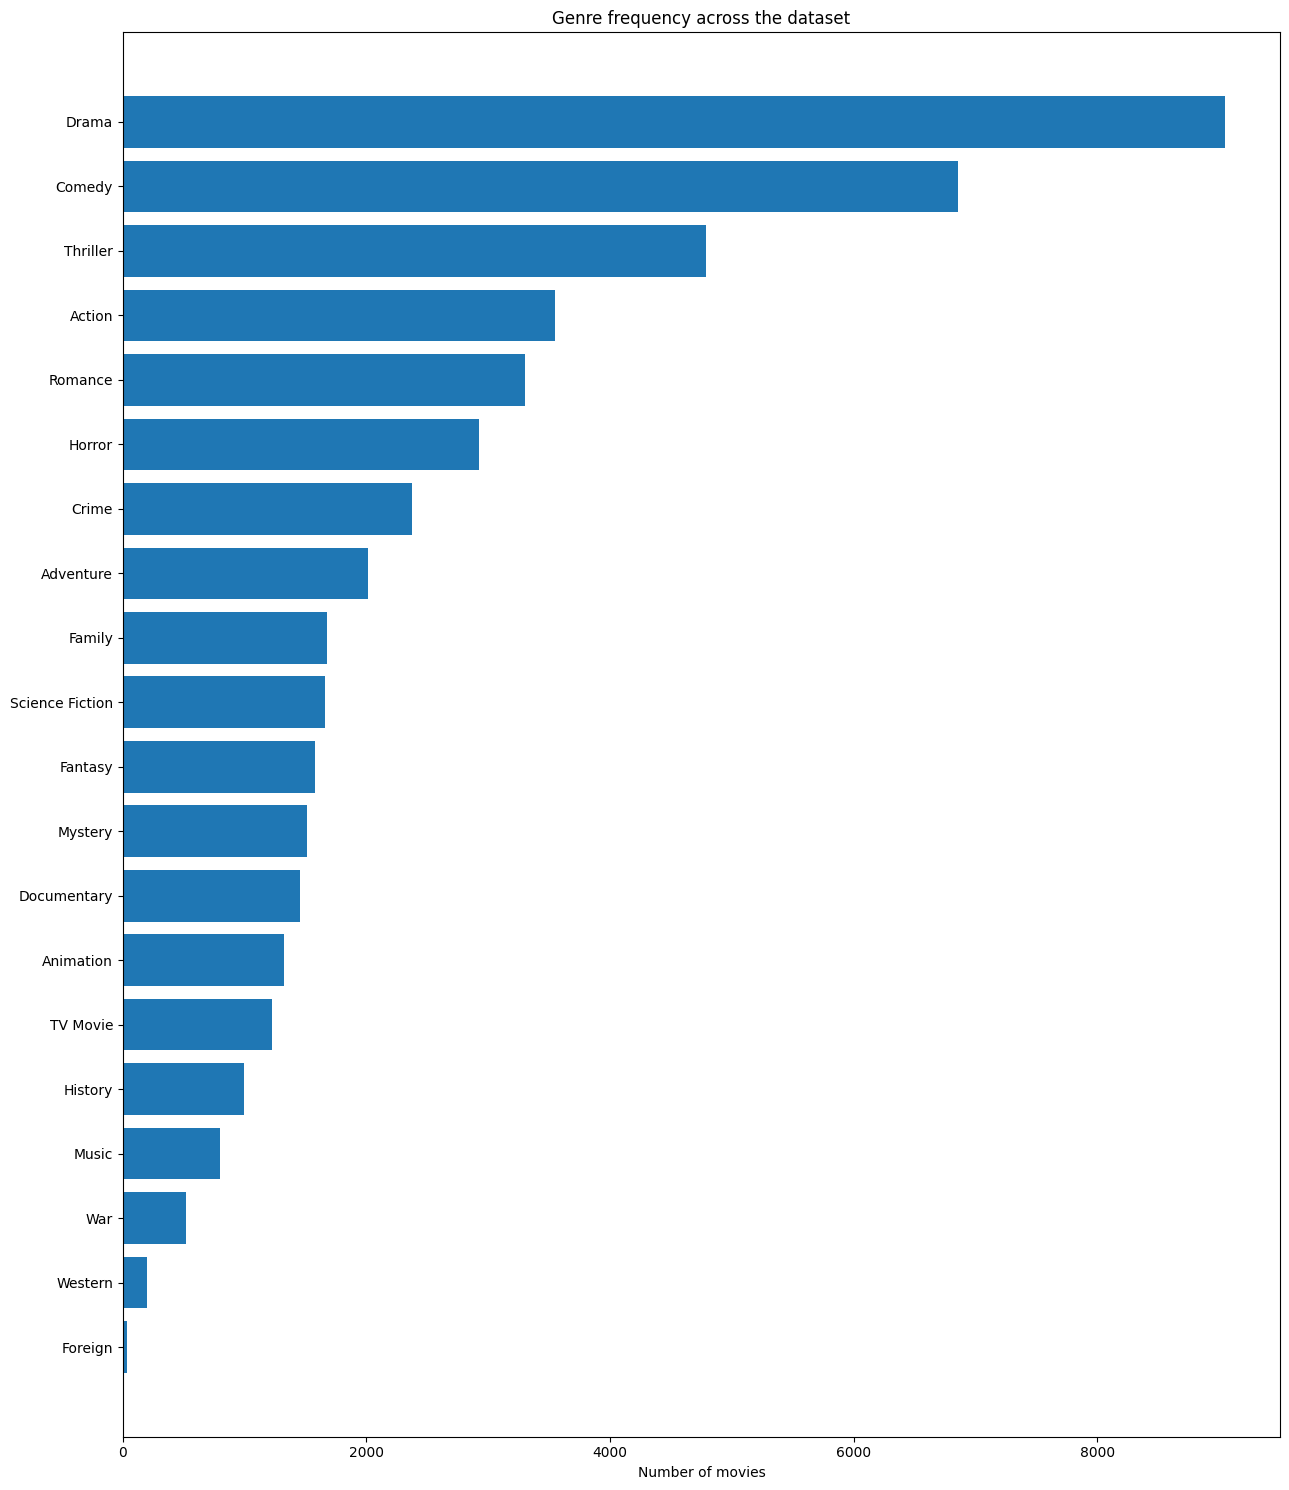

In [123]:
##Which Genre is the most occuring in the dataset.
genre_counts = Counter()
for lst in df_copy['genres']:
    genre_counts.update(lst)

genres, counts = zip(*genre_counts.most_common())  # sorted descending automatically

plt.figure(figsize=(13, 15))
plt.barh(genres[::-1], counts[::-1])  # reverse so the biggest bar is on top
plt.xlabel('Number of movies')
plt.title('Genre frequency across the dataset')
plt.tight_layout()
plt.show()

#### Concludes that most movie share the Drama Genre and is not a differentiator but still helpful

In [124]:
## Number of unique directors in the dataset and the top 20 directors.
director_counts = Counter(df_copy['director'].dropna())
print('unique directors:', len(director_counts))
print('top 20:')
for name, cnt in director_counts.most_common(20):
    print(f'  {name}: {cnt}')

unique directors: 11875
top 20:
  : 89
  Steven_Spielberg: 31
  Steven_Soderbergh: 25
  Clint_Eastwood: 25
  Woody_Allen: 24
  Terry_Ingram: 24
  Martin_Scorsese: 23
  Tyler_Perry: 23
  Michael_Robison: 23
  Renny_Harlin: 22
  Robert_Rodriguez: 22
  Ridley_Scott: 21
  Ron_Howard: 20
  Spike_Lee: 20
  Kevin_Fair: 19
  Sean_McNamara: 18
  David_Weaver: 18
  Robert_Zemeckis: 17
  Tim_Burton: 16
  Oliver_Stone: 16


<Axes: title={'center': 'Top 20 Directors by Number of Movies'}, xlabel='director'>

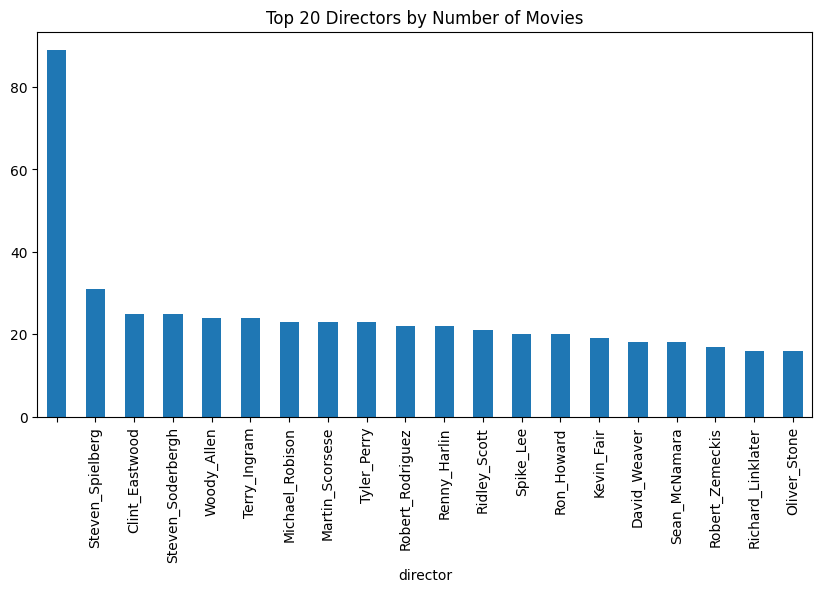

In [125]:
df_copy['director'].value_counts().head(20).plot(kind='bar', figsize=(10,5), title='Top 20 Directors by Number of Movies')

In [128]:
production_company_counts = Counter(df_copy['production_companies_filtered'].dropna().explode())
print('unique production companies:', len(production_company_counts))
print('top 20:')
for name, cnt in production_company_counts.most_common(20):
    print(f'  {name}: {cnt}')

unique production companies: 10162
top 20:
  Universal: 449
  Warner Bros: 412
  Paramount: 397
  Columbia Pictures: 372
  20th Century Studios: 299
  Disney: 286
  RAI Cinema: 235
  MGM: 234
  France 2 Cinéma: 228
  Hallmark Media: 211
  New Line: 210
  Lionsgate: 203
  France 3 Cinéma: 199
  Canal+: 185
  DreamWorks: 164
  Lifetime: 153
  StudioCanal: 151
  ARTE France Cinéma: 150
  MiC: 133
  Miramax: 130


C:\Users\ADRIJO\AppData\Local\Temp\ipykernel_21740\1004705160.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


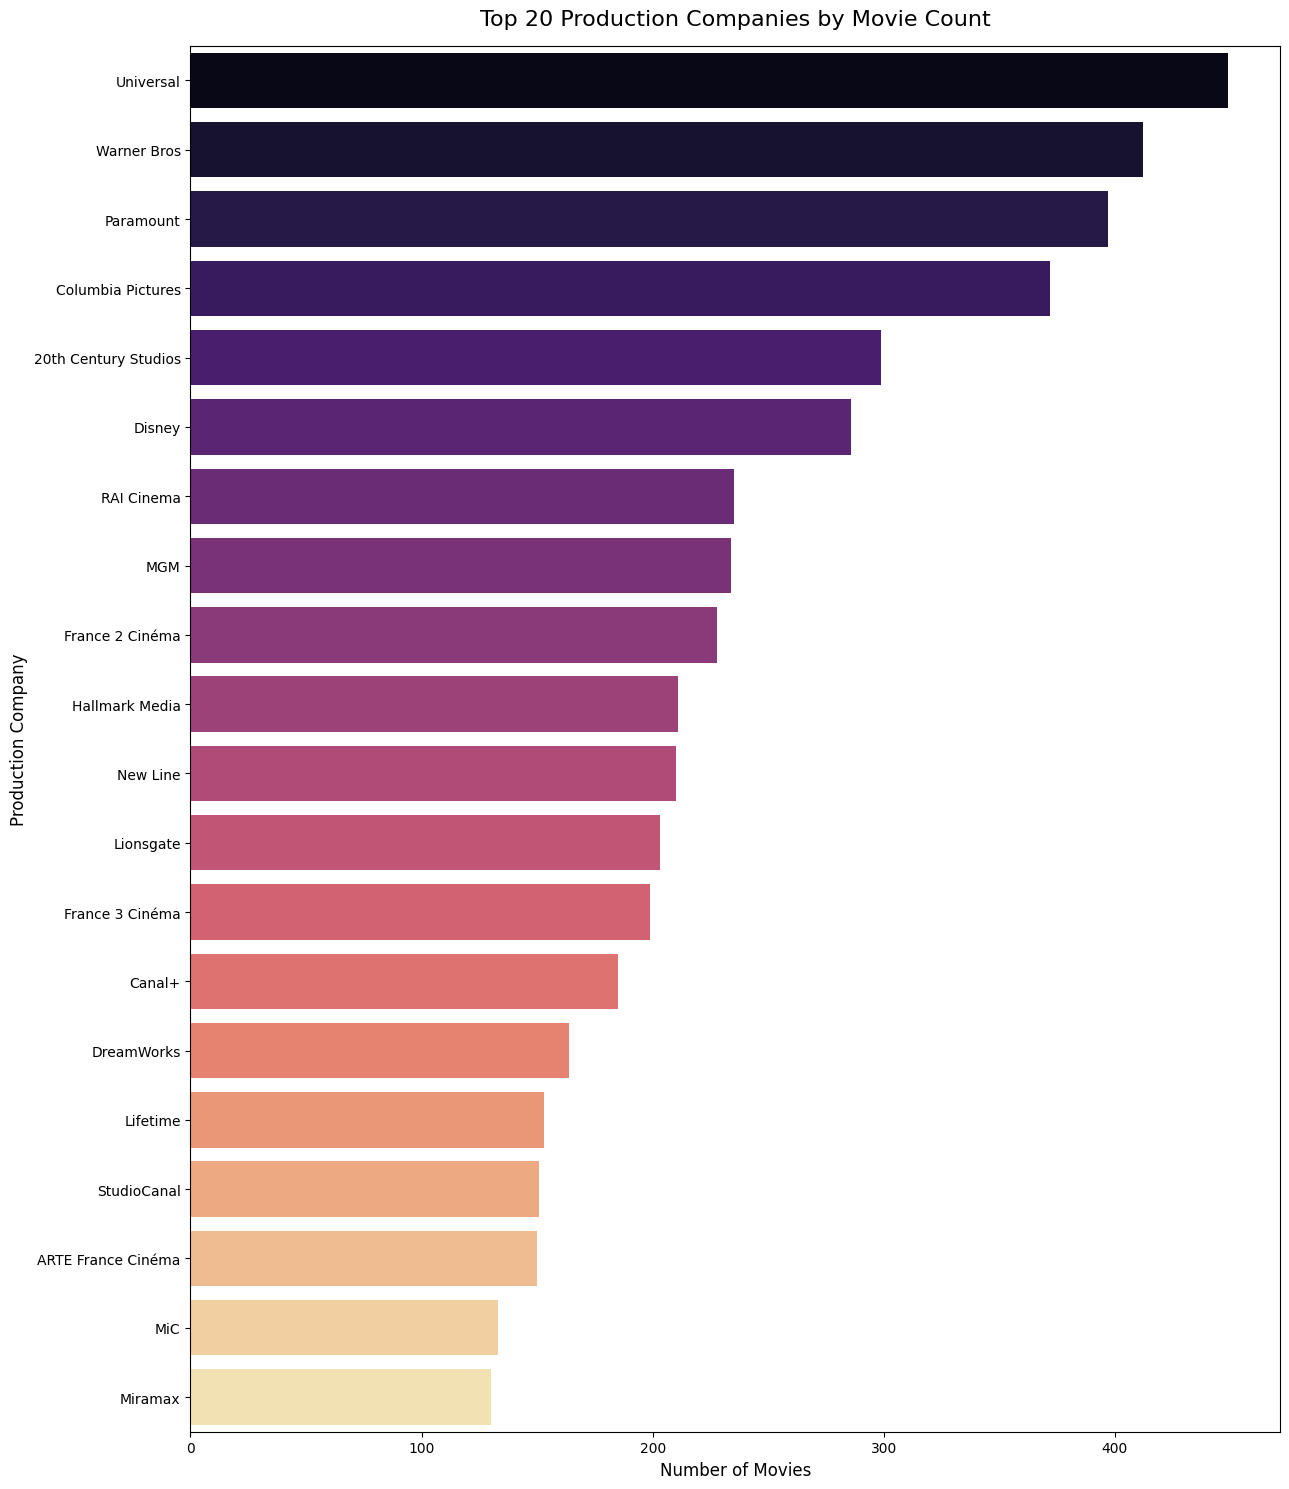

In [129]:
top_20_companies = production_company_counts.most_common(20)
df_top20 = pd.DataFrame(top_20_companies, columns=['Company', 'Count'])
plt.figure(figsize=(13, 15))
sns.barplot(
    data=df_top20, 
    x='Count', 
    y='Company', 
    palette='magma'
)
plt.title('Top 20 Production Companies by Movie Count', fontsize=16, pad=15)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Production Company', fontsize=12)

plt.tight_layout()
plt.show()